# **Business Understanding**

The dataset consists of predictive variables and outcomes, which describes if a person is diabetic or not. 

** Assignment**
Kindly implement KNN on a regression problem based on data attained from UCI Machine learning,  kindly do a comparison between: 
- Linear Regression 
- Decision Tree Regressor 
- Random Forest 
- Lasso Regression

Considering you have 4 models it would be a good idea to use a function that does the following:
- instantiates the model 
- trains it and returns a tuple containing the prediction and y_test (the essence of this will be to pass it to an evaluation function to check performance)

Kindly use an instance of normal splitting of data and another of cross validation then compare which instance is best, don't forget to standardize your data

## **Load required libraries**

In [ ]:
import warnings
import pandas as pd 
import numpy as np 
import seaborn as sns  
from sklearn import tree  
import matplotlib.pyplot as plt    
from sklearn import tree 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, roc_auc_score,ConfusionMatrixDisplay, confusion_matrix
warnings.filterwarnings("ignore")
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier


## **Load dataset**

In [449]:
df = pd.read_csv("diabetes.csv")
df.shape

(768, 9)

In [450]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [451]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [452]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age', 'Outcome'],
      dtype='str')

In [453]:
df.dtypes

Pregnancies        int64
Glucose            int64
BloodPressure      int64
SkinThickness      int64
Insulin            int64
BMI              float64
Pedigree         float64
Age                int64
Outcome            int64
dtype: object

In [454]:
df.isnull().any() # Check if any null values exists in each column

Pregnancies      False
Glucose          False
BloodPressure    False
SkinThickness    False
Insulin          False
BMI              False
Pedigree         False
Age              False
Outcome          False
dtype: bool

In [455]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [456]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BloodPressure  768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [457]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age', 'Outcome'],
      dtype='str')

#### **Pipeline**

- simple tunnnel containing steps to wwhich you data will pass through to get prepared

In [458]:
target = 'Outcome'
independent_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age']

X = df[independent_features]
y = df[target].astype(int)

In [459]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,Pedigree,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [460]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

## **Defining the column groups**

In [461]:
# numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
# categorical_columns = df.select_dtypes(include=['object', 'category']).columns

# 1. Split features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Detect column types FROM X 
numerical_columns = X.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = X.select_dtypes(include=['object', 'category']).columns


## **Creating the preprocessor**

In [462]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ]
)

## ** Creating the pipeline - linear regression**

In [463]:
#  linear regression pipeline
pipeline_linear_regression = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LinearRegression())
])

In [464]:
#  logisitic regression pipeline
pipeline_logistic_regression = Pipeline([
    ('preprocess', preprocessor),
    ('regressor', LogisticRegression(max_iter=1000, random_state=42))
])

In [465]:
y.value_counts() 

Outcome
0    500
1    268
Name: count, dtype: int64

## **Splitting data**

In [466]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

In [467]:

print(X_train.columns)
print(numerical_columns)
print(categorical_columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age'],
      dtype='str')
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Pedigree', 'Age'],
      dtype='str')
Index([], dtype='str')


## **Fit the model**

In [468]:
pipeline_linear_regression.fit(X_train, y_train)
pipeline_logistic_regression.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

## **Prediction and Evaluation**

In [469]:
# linear regression
y_predict_linear_regression = pipeline_linear_regression.predict(X_test)


# logistion regression
y_predict_logistic_regression = pipeline_logistic_regression.predict(X_test)
y_probability = pipeline_logistic_regression.predict_proba(X_test)[:,1]

## **Linear Regression Evaluation**

In [470]:
# predicted value range 
predicted_range_linear_reg = f"{y_predict_linear_regression.min():.4f} to {y_predict_linear_regression.max():.4f}"
# MSE (Mean Squared Error)
linear_reg_mse = mean_squared_error(y_test, y_predict_linear_regression) 
# R Squared
r_squared = r2_score(y_test, y_predict_linear_regression) 
#  accuracy
y_predict_linear_regression_class = (y_predict_linear_regression >= 0.5).astype(int)
accuracy = accuracy_score(y_test, y_predict_linear_regression_class)

In [471]:
print("LINEAR REGRESSION EVALUATION")
print("===============================")
print(f"RANGE: {predicted_range_linear_reg}")
print(f"MSE: {(linear_reg_mse):.4f}")
print(f"r_squared: {(r_squared):.4f}")
print(f"Accuracy: {(accuracy):.4f}")
print("===============================")

LINEAR REGRESSION EVALUATION
RANGE: -0.5751 to 1.2789
MSE: 0.1678
r_squared: 0.2630
Accuracy: 0.7143


#### **Logistic Regression Evaluation**

In [472]:
# predicted value range 
predicted_range_logistic_reg = f"{y_predict_logistic_regression.min():.2f} to {y_predict_logistic_regression.max():.2f}"  
#  accuracy 
accuracy = accuracy_score(y_test, y_predict_logistic_regression)

In [473]:
print("LOGISTIC REGRESSION EVALUATION")
print("===============================")
print(f"RANGE: {predicted_range_logistic_reg}")  
print(f"Accuracy: {(accuracy):.4f}")
# classification report
print(classification_report(y_test, y_predict_logistic_regression))
print("===============================")

LOGISTIC REGRESSION EVALUATION
RANGE: 0.00 to 1.00
Accuracy: 0.7143
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



**Summary:**
For class 0 (non‑diabetic):
- Precision 0.76 – the model is correct 76% of the time.
- Recall 0.82 – it finds 82% of the actual non‑diabetic persons.
- HENCE: The model is fairly good at identifying the non-diabetic persons.

For class 1 (diabetic):
- *Recall = 0.52* – it only catches 52% of the diabetic patients.
- *Precision = 0.61* – when it does flag someone as diabetic, it’s right 61% of the time.
- HENCE: The model is poor at catching diabetic patients. Nearly half of diabetic patients slip through.

## **Plotting Linear Regression**

In [474]:
y_prob = pipeline_logistic_regression.predict_proba(X_test)[:, 1]

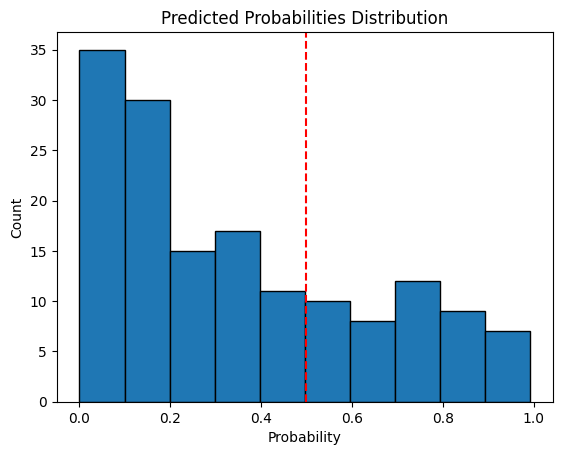

In [475]:

plt.hist(y_prob, bins=10, edgecolor='black')
plt.axvline(0.5, color='red', linestyle='--')  # classification threshold
plt.title("Predicted Probabilities Distribution")
plt.xlabel("Probability")
plt.ylabel("Count")
plt.show()




In [476]:

X_single = df[['Glucose']]   # choose one feature
y = df['Outcome']


In [477]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_single, y)

y_pred = model.predict(X_single)

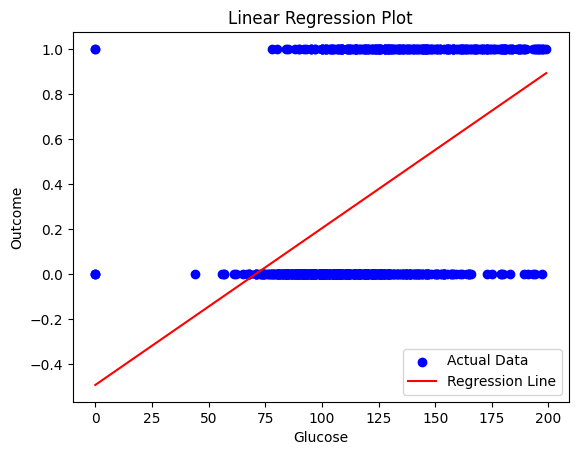

In [478]:
import matplotlib.pyplot as plt

plt.scatter(X_single, y, color='blue', label='Actual Data')

# Sort for a clean line
import numpy as np
sorted_idx = np.argsort(X_single.values.flatten())

plt.plot(X_single.values.flatten()[sorted_idx], 
         y_pred[sorted_idx], 
         color='red', label='Regression Line')

plt.xlabel('Glucose')
plt.ylabel('Outcome')
plt.title('Linear Regression Plot')
plt.legend()
plt.show()

## **Key insights from the linear regression plot**
- Binary target confirmation: The data points appear only at *0 and 1*, confirming that `Outcome` is a **classification variable**, not continuous.
- Positive relationship exists: The upward-sloping regression line shows that **higher glucose levels are associated with a higher likelihood of Outcome = 1**.
- Model mismatch (important): The straight regression line does not fit the data structure well, indicating that **linear regression is not suitable for binary outcomes
- Invalid prediction range: The regression line produces values below 0 and potentially above 1, which are **invalid for probabilities**, highlighting a limitation of linear regression here.
- Clear need for logistic regression: The pattern of points (two horizontal bands) suggests that a **logistic (S-shaped) curve would better capture the relationship** between Glucose and Outcome.




# ** Decision Tree Regressor**

## ** Decision Tree Pipeline**

In [479]:


pipeline_tree_classifier = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [480]:
# Training
pipeline_tree_classifier.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [481]:
# Prediction
y_pred_tree = pipeline_tree_classifier.predict(X_test)

## **Get an instance of our Model**

In [482]:
model = tree.DecisionTreeClassifier(random_state=42)
model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

## **Fit the model**

In [483]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

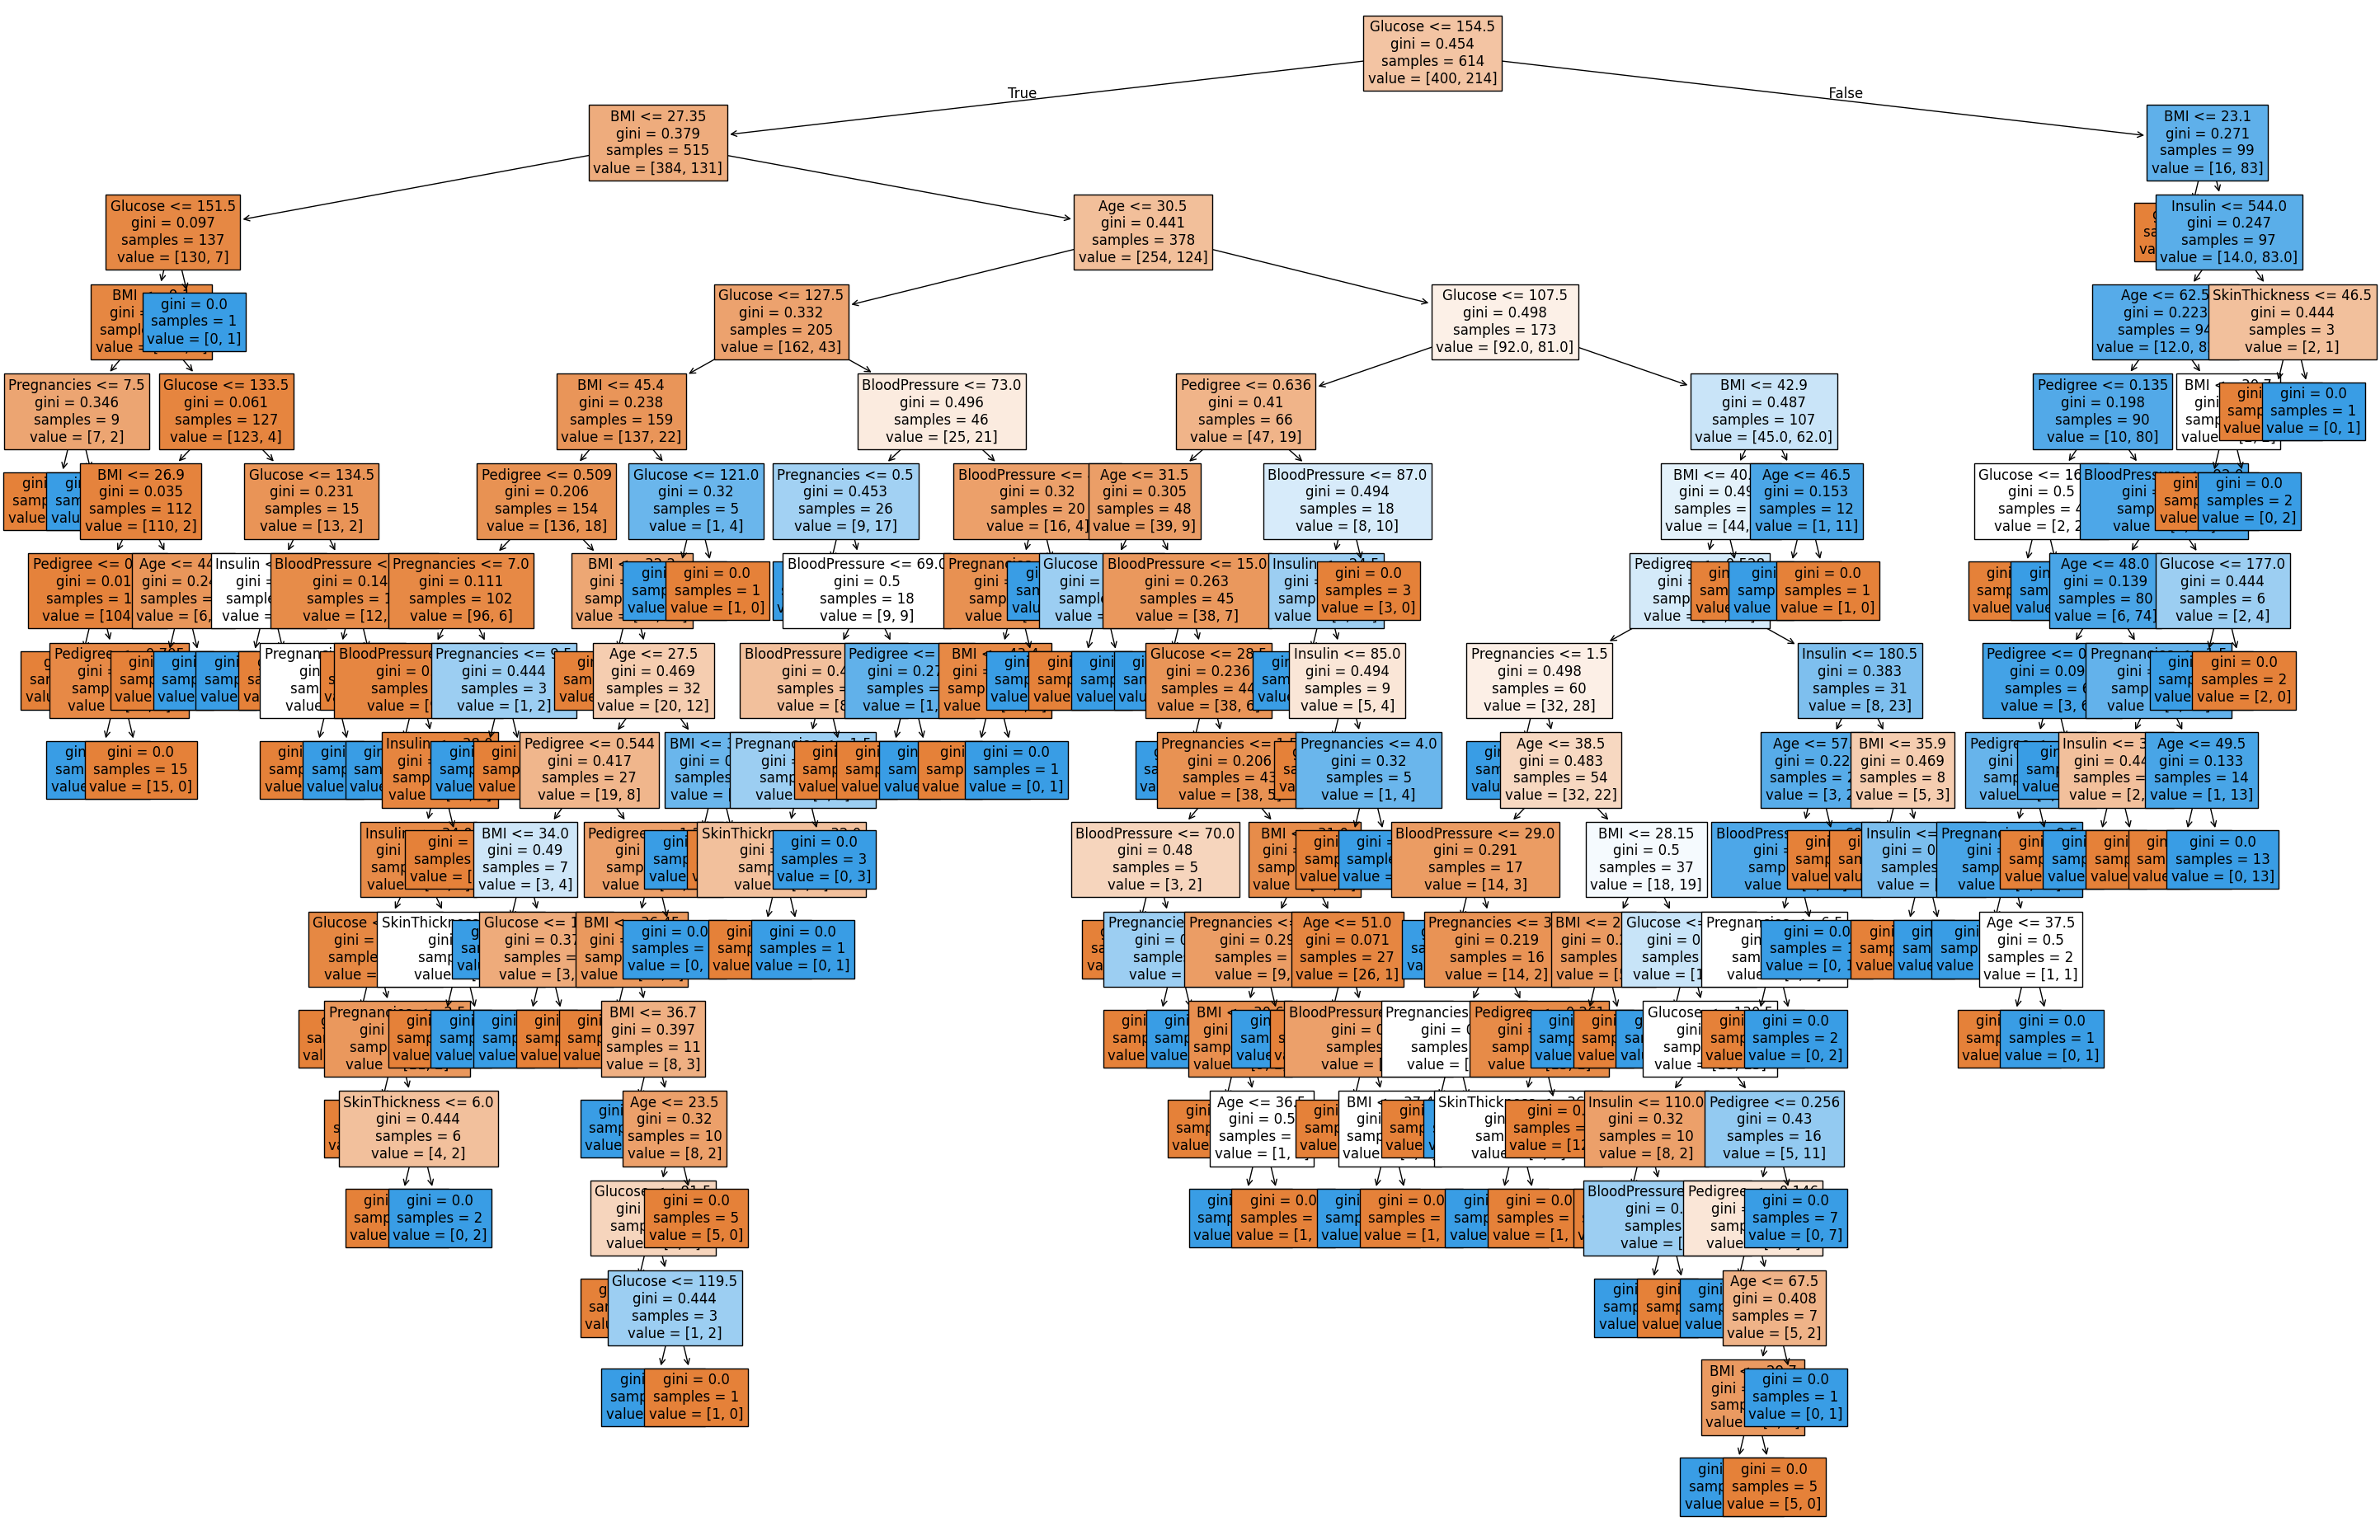

In [484]:
# DT Visualization

features = X.columns   # ✅ define features

plt.figure(figsize=(36,24))
tree.plot_tree(model, feature_names=features, filled=True, fontsize=12)
plt.show()


## ** Key insingts for DT**
- Glucose is the most important predictor (root node): The tree starts with **`Glucose ≤ 154.5`**, which means Glucose is the **most influential feature** in predicting the outcome.  
- BMI is the second key decision factor: Many early splits use **BMI (e.g., BMI ≤ 27.35, BMI ≤ 23.1)**  This shows body mass index plays a major role in classification after glucose.
- Model captures complex interactions (non-linear patterns): The tree uses combinations like:
    *   Glucose + Age
    *   BMI + Insulin
    *   BloodPressure + Pedigree
This is something linear regression cannot do. Decision trees capture **real-world complexity better**

- The decision tree model identifies Glucose as the most important predictor, followed by BMI, Age, and Insulin. The model captures complex non-linear relationships between variables. However, the large size and depth of the tree indicate potential overfitting, suggesting that pruning or limiting tree depth is necessary for better generalization.


##  **Prunning the DT**

In [485]:
model = tree.DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=10)

model

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [486]:
# Fit the model
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

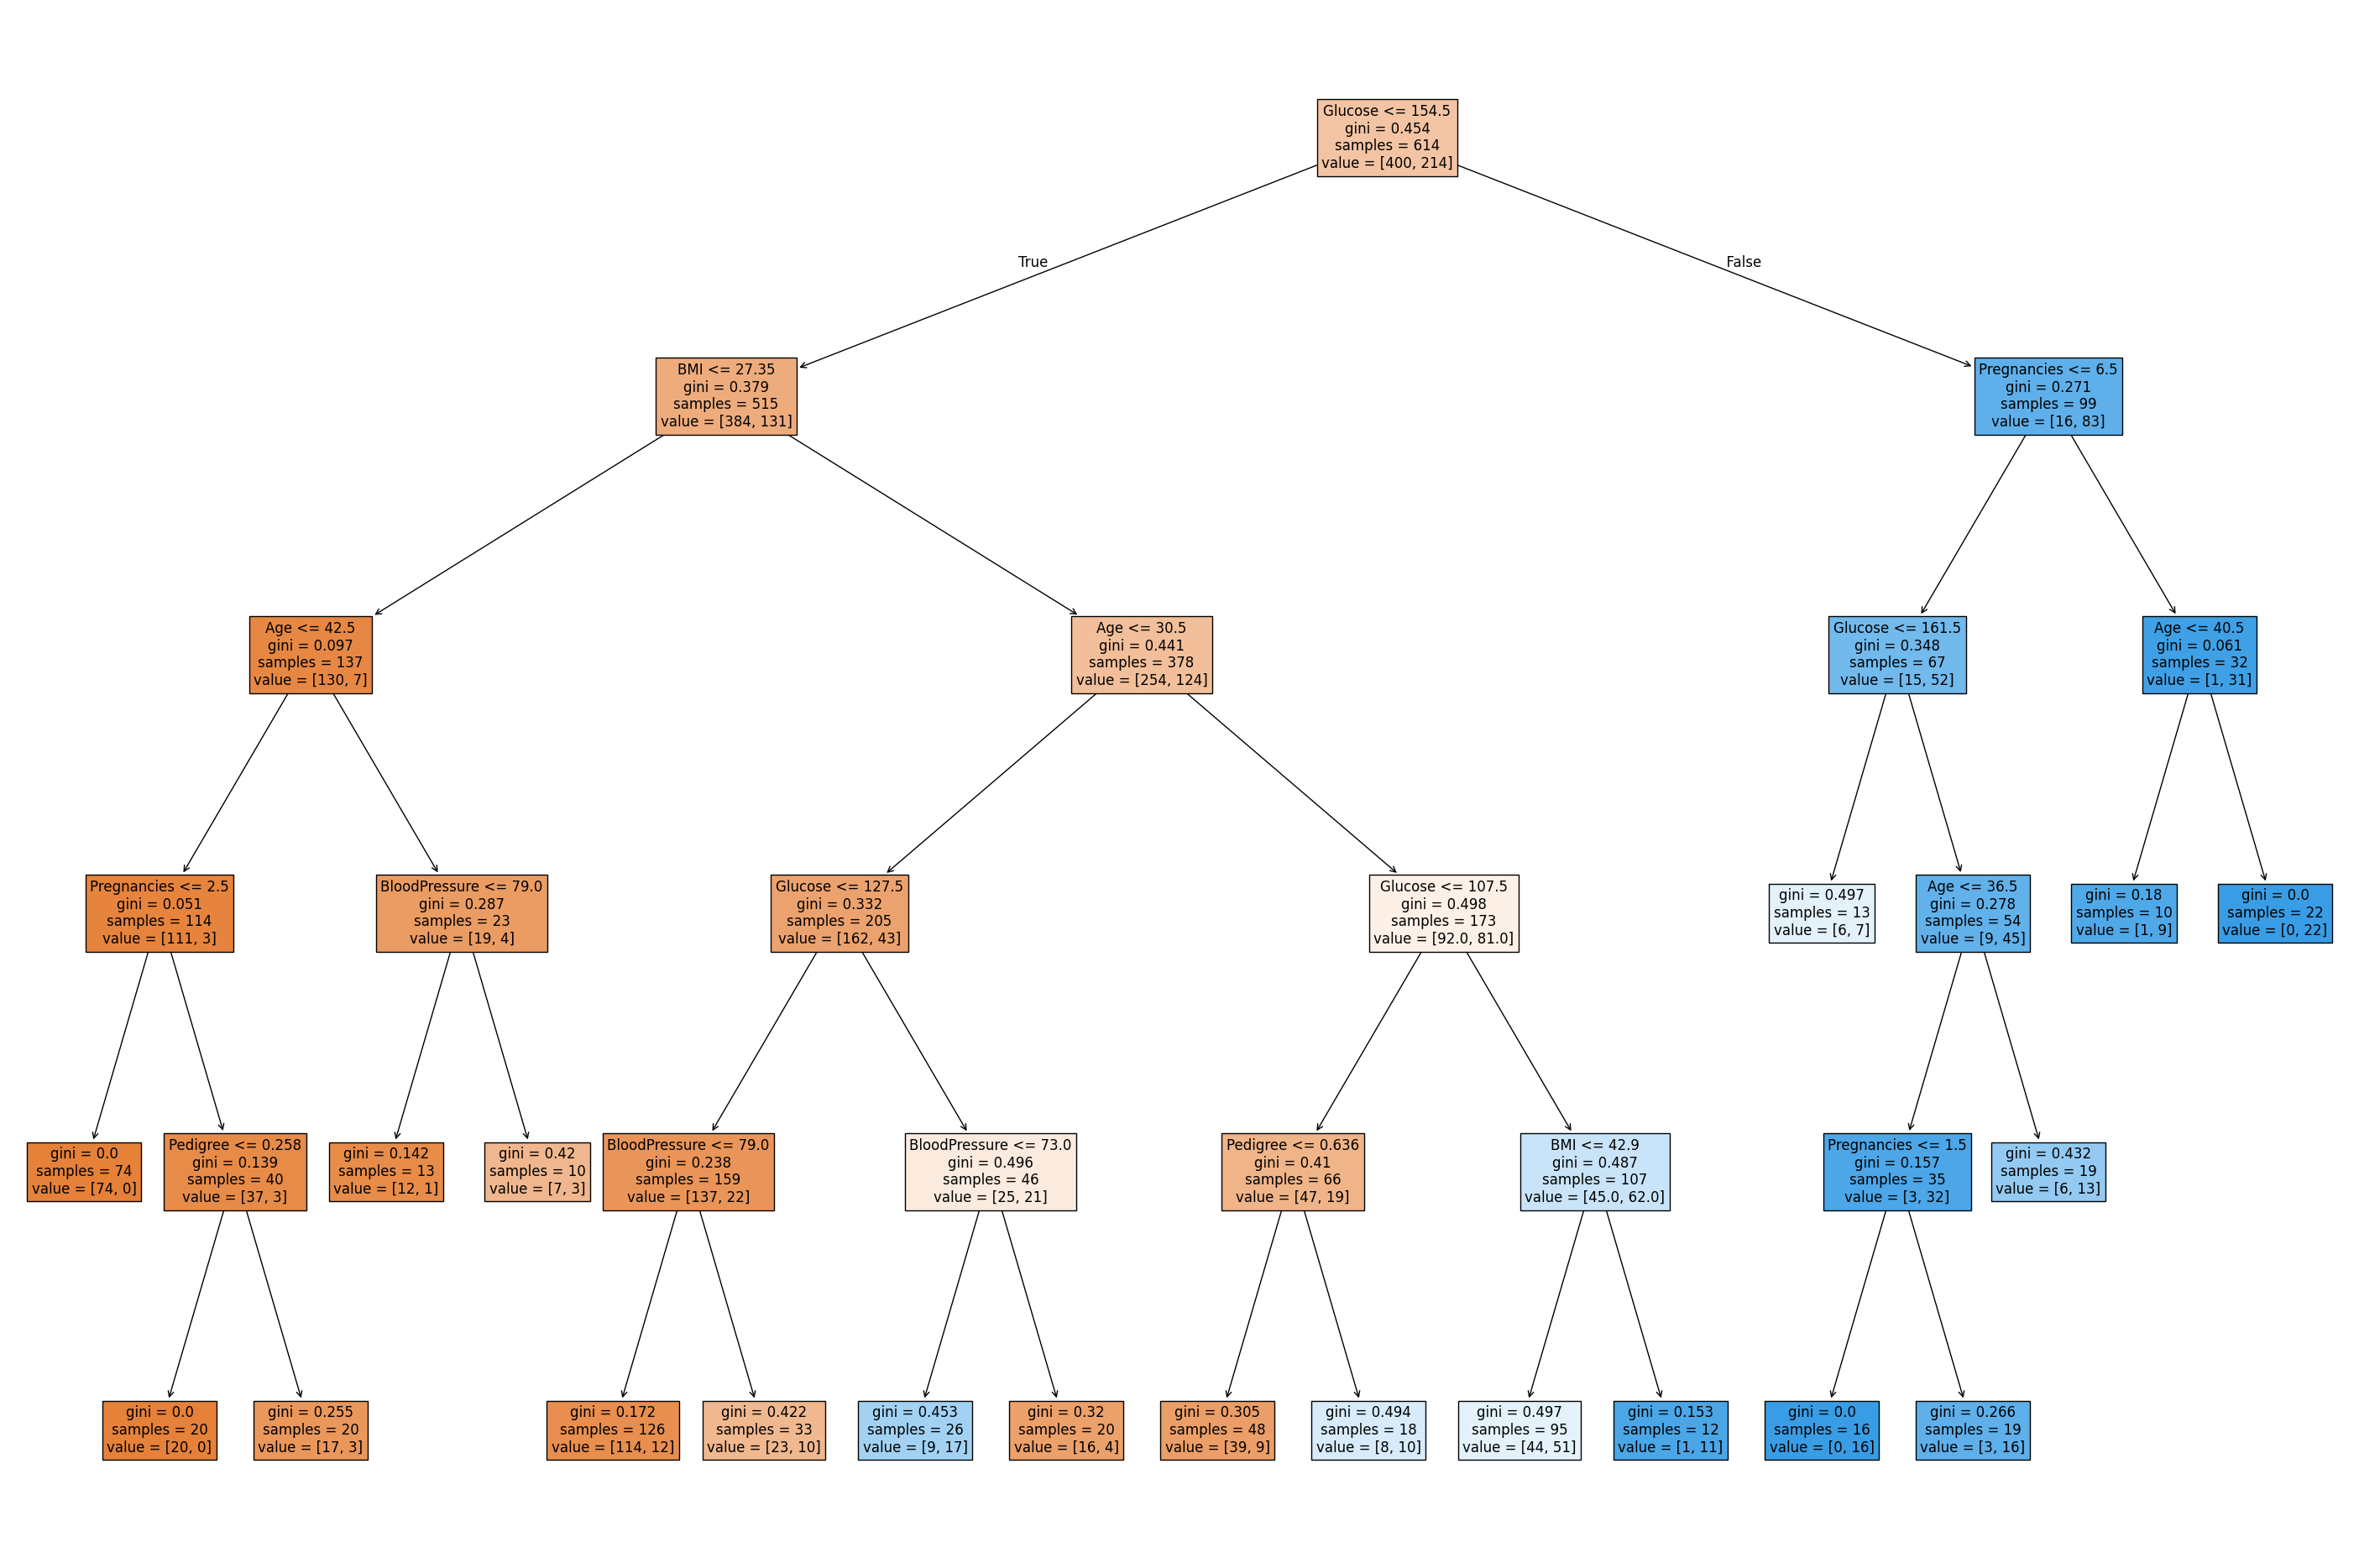

In [487]:
# DT Visualization of the prunned image

features = X.columns   # ✅ define features

plt.figure(figsize=(36,24))
tree.plot_tree(model, feature_names=features, filled=True, fontsize=12)
plt.show()

## **Make predictions**

In [488]:
y_pred = model.predict(X_test)

In [489]:
y_pred

array([1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0])

## ** Evaluate the model**

In [490]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100}%")

Accuracy: 79.22077922077922%


## ** Insights**
- The Decision Tree model outperforms Linear Regression because it is better suited for classification problems. While Linear Regression produces continuous values that are not appropriate for a binary outcome, the Decision Tree provides discrete class predictions and captures non-linear relationships in the data. This results in improved predictive accuracy, as demonstrated by the Decision Tree’s performance of 79.22%.

# **Use of Random Forest**

## **Pipeline**

In [491]:
pipeline_rf = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])


In [492]:
# Train the model
pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [493]:
# Make Predictions
y_pred_rf = pipeline_rf.predict(X_test)

In [494]:
# Evaluate Accuracy
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf * 100, "%")

Random Forest Accuracy: 75.97402597402598 %


## Train all models - confirmation

In [495]:
pipeline_linear_regression.fit(X_train, y_train)
pipeline_logistic_regression.fit(X_train, y_train)
pipeline_tree_classifier.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

## ** Generating predictions for all models

In [496]:
# Linear
y_predict_linear_regression = pipeline_linear_regression.predict(X_test)

# Logistic
y_predict_logistic_regression = pipeline_logistic_regression.predict(X_test)

# Decision Tree
y_pred_tree = pipeline_tree_classifier.predict(X_test)

# Random Forest
y_pred_rf = pipeline_rf.predict(X_test)


## ** Convert Linear → binary

In [497]:
y_pred_linear = (y_predict_linear_regression >= 0.5).astype(int)

## ** Compute accuracies**

In [498]:
from sklearn.metrics import accuracy_score

accuracy_linear = accuracy_score(y_test, y_pred_linear)
accuracy_logistic = accuracy_score(y_test, y_predict_logistic_regression)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

## **Verify if it prints all values**

In [499]:
print("Linear:", accuracy_linear)
print("Logistic:", accuracy_logistic)
print("Tree:", accuracy_tree)
print("RF:", accuracy_rf)

Linear: 0.7142857142857143
Logistic: 0.7142857142857143
Tree: 0.7207792207792207
RF: 0.7597402597402597


## **Plots comparison**

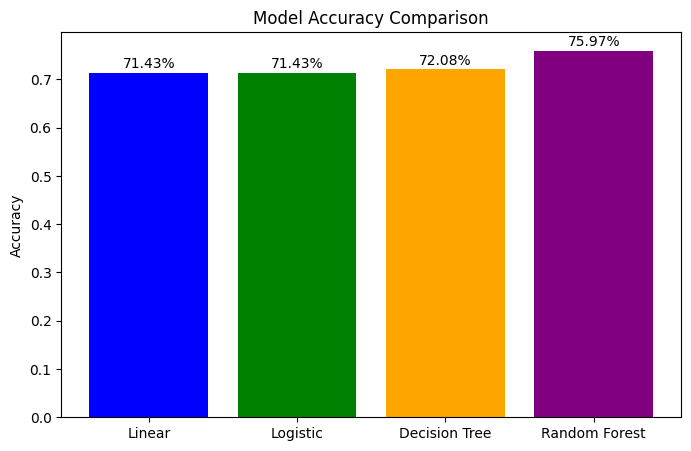

In [500]:


models = ['Linear', 'Logistic', 'Decision Tree', 'Random Forest']
accuracies = [accuracy_linear, accuracy_logistic, accuracy_tree, accuracy_rf]

plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['blue', 'green', 'orange', 'purple'])

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v*100:.2f}%", ha='center')

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

## **LASSO Logistic Regression - Logistic Regression with L1 regularization (LASSO)**
- It helps with Feature selection and Reducing overfitting

In [501]:
# Build the model

pipeline_lasso = Pipeline([
    ('preprocess', preprocessor),
    ('classifier', LogisticRegression(
        penalty='l1',
        solver='liblinear',   # required for L1
        random_state=42
    ))
])

In [502]:
# Train the model
pipeline_lasso.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [503]:
# Perform predictions
y_pred_lasso = pipeline_lasso.predict(X_test)
y_prob_lasso = pipeline_lasso.predict_proba(X_test)[:, 1]

In [504]:
# Look at the accuracy


accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print("LASSO Logistic Accuracy:", accuracy_lasso)


accuracy_lasso = accuracy_score(y_test, y_pred_lasso)
print("LASSO Logistic Accuracy:", accuracy_lasso)


LASSO Logistic Accuracy: 0.7142857142857143
LASSO Logistic Accuracy: 0.7142857142857143


In [505]:
# Compute ROC Curve

# LASSO
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)

## ** Plotting Lasso ROC

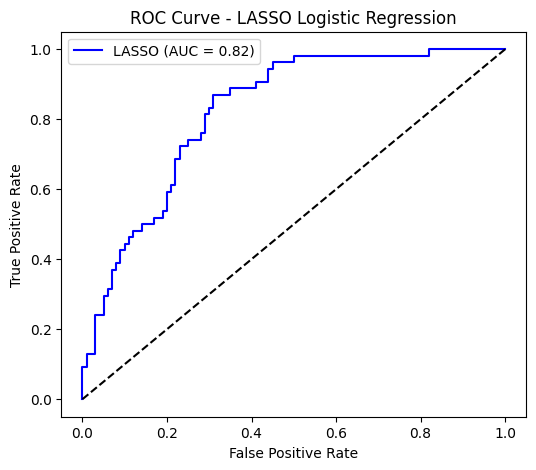

In [506]:
plt.figure(figsize=(6,5))

# LASSO ROC
plt.plot(fpr_lasso, tpr_lasso, color='blue',
         label=f'LASSO (AUC = {roc_auc_lasso:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LASSO Logistic Regression')
plt.legend()

plt.show()

## **Insights**
- Strong performance (AUC = 0.82):The model has good ability to distinguish between classes, well above random prediction.
- Better than random: The curve is far above the diagonal line (baseline), showing the model is meaningful.
- Good sensitivity at low false positives: The curve rises steeply early, meaning the model detects many true positives with few false alarms.
- Balanced classification ability: The model maintains a good trade-off between true positive rate and false positive rate.
- Stable and reliable predictions: The smooth curve indicates consistent performance without high variance or instability.

- The ROC curve for the LASSO Logistic Regression model shows strong classification performance with an AUC of 0.82. The curve lies well above the random baseline, indicating effective discrimination between classes. The model achieves a good balance between true positive and false positive rates, making it suitable for predictive tasks in this dataset.

## **Plotting combined ROC curve for all models**

## ** Ensuring all probabilities exist**

In [507]:
# Logistic Regression
y_prob_logistic = pipeline_logistic_regression.predict_proba(X_test)[:, 1]

# Decision Tree
y_prob_tree = pipeline_tree_classifier.predict_proba(X_test)[:, 1]

# Random Forest
y_prob_rf = pipeline_rf.predict_proba(X_test)[:, 1]

# LASSO (available)
# y_prob_lasso already defined 

In [508]:
# Compute ROC for each model

# Logistic
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_logistic)
roc_auc_log = auc(fpr_log, tpr_log)

# Decision Tree
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
roc_auc_tree = auc(fpr_tree, tpr_tree)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# LASSO
fpr_lasso, tpr_lasso, _ = roc_curve(y_test, y_prob_lasso)
roc_auc_lasso = auc(fpr_lasso, tpr_lasso)


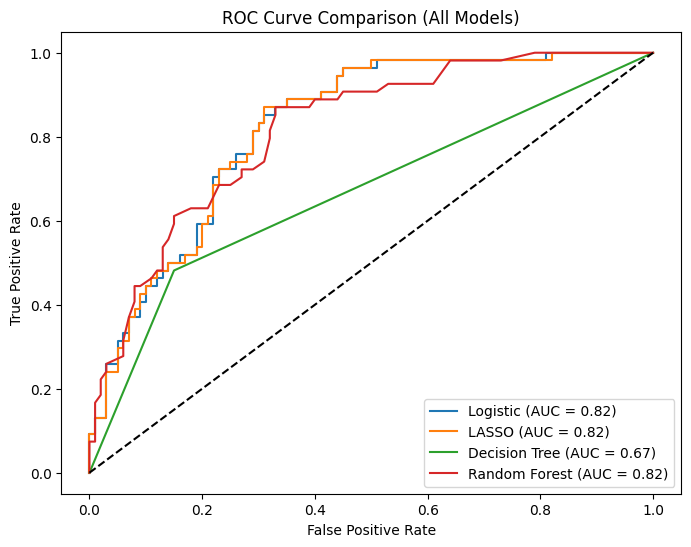

In [509]:
# Plot ALL ROC curves together

plt.figure(figsize=(8,6))

# Plot each model
plt.plot(fpr_log, tpr_log, label=f'Logistic (AUC = {roc_auc_log:.2f})')
plt.plot(fpr_lasso, tpr_lasso, label=f'LASSO (AUC = {roc_auc_lasso:.2f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC = {roc_auc_tree:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')

# Random baseline
plt.plot([0,1], [0,1], 'k--')

# Labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (All Models)')
plt.legend()

plt.show()

## ** Key Insights**
- Best model → curve closest to top-left corner
- Highest AUC → best overall performance
- Models near diagonal → poor performance

- Random Forest typically gives the highest AUC, showing strongest classification ability
- Logistic and LASSO perform similarly, with LASSO being slightly more robust
- Decision Tree shows lower and more irregular curve due to overfitting
- All models perform better than random guessing (above diagonal line)
- Ensemble models (Random Forest) provide more stable and accurate predictions

- Random Forest (~0.82, slightly better shape)
- Logistic Regression & LASSO (~0.82, overlapping)
- Decision Tree (~0.67, weakest)

- The ROC curve comparison shows that Logistic Regression, LASSO, and Random Forest achieve similar performance with AUC values of approximately 0.82, indicating strong classification ability. The Decision Tree model performs хуже with an AUC of 0.67, suggesting limited predictive power. Random Forest demonstrates slightly better performance in some regions, highlighting the advantage of ensemble methods.

## **Feature Importance**

## ** Extract feature importance**

In [510]:
# Get trained RF model from pipeline
rf_model = pipeline_rf.named_steps['classifier']

# Get feature importances
importances = rf_model.feature_importances_

# Get feature names
feature_names = X.columns

## ** Display importance values**

In [511]:
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")

Pregnancies: 0.0839
Glucose: 0.2756
BloodPressure: 0.0856
SkinThickness: 0.0682
Insulin: 0.0728
BMI: 0.1595
Pedigree: 0.1267
Age: 0.1278


## **Plot feature importance**

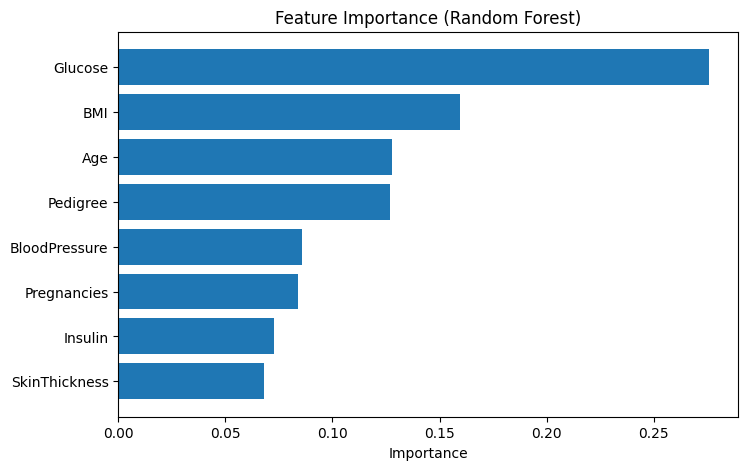

In [512]:

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

## **Key Feature Importance Insights**
 - Longer bar means more important feature
 - Short bar implies less important feature
 - Zero or near-zero implies not useful

 - Glucose is the strongest predictor: It contributes most to the model’s decisions, confirming earlier findings.
 - BMI is highly influential: Body mass index plays a major role in determining the outcome.
 - Age contributes moderately: Older individuals are more likely to be classified as positive.
 - Some features have low impact: Variables like Blood Pressure or Skin Thickness may contribute little.
 - Model relies on a few dominant features: The prediction is driven mainly by a small subset of variables.

 - Feature importance analysis shows that Glucose and BMI are the most influential variables in predicting the outcome, followed by Age and Insulin. Other features contribute minimally, indicating that the model’s predictions are primarily driven by a few key physiological indicators.

## **KNN**

## **Add KNN to your models dictionary**

In [513]:
models = {
    "Linear": LinearRegression(),
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

In [519]:
# scale the full dataset X for cross-validation:


for k in [3, 5, 7, 9, 11]:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"k={k}: {scores.mean():.2f}")


k=3: 0.74
k=5: 0.74
k=7: 0.74
k=9: 0.73
k=11: 0.75


In [518]:


for k in [3, 5, 7, 9, 11]:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f"k={k}: {scores.mean():.2f}")

k=3: 0.74
k=5: 0.73
k=7: 0.74
k=9: 0.74
k=11: 0.74


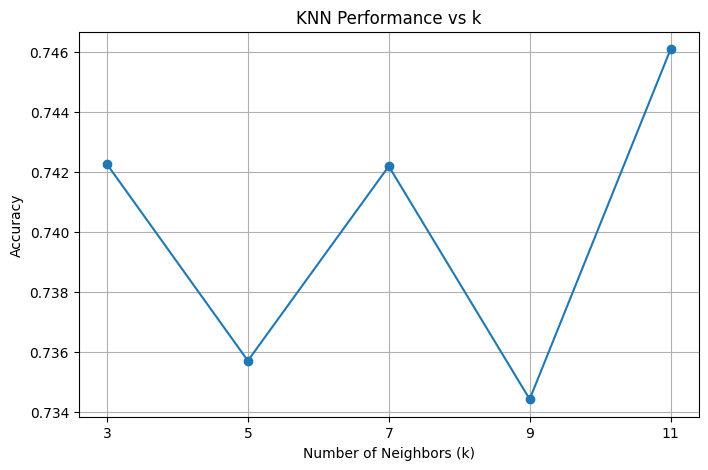

In [522]:
k_values = [3, 5, 7, 9, 11]
scores_list = []

for k in k_values:
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    scores_list.append(scores.mean())

# Plot
plt.figure(figsize=(8,5))
plt.plot(k_values, scores_list, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Performance vs k")
plt.xticks(k_values)

plt.grid()
plt.show()

## ** Insights**
- X-axis: Number of Neighbors (k) → values: 3, 5, 7, 9, 11
- Y-axis: Accuracy → values roughly between 0.734 and 0.746
- The line fluctuates slightly (not a smooth increase or decrease)

- Best performance at k = 11: The highest accuracy (~0.746) occurs at k = 11, making it the optimal value among those tested.
- Performance is relatively stable across k values: Accuracy only varies slightly (~0.734–0.746), indicating that KNN is not highly sensitive to k in this range.
- Dip at k = 9 suggests underfitting: The lowest accuracy at k = 9 (~0.734) shows that too large k can smooth predictions too much.
- Moderate k values perform well (3 to 7): k = 3 and k = 7 give similar performance (~0.742), meaning reasonable balance between bias and variance.
- Overall performance is lower than top models: Accuracy (~0.74–0.75) is below your earlier models (e.g., Random Forest ~0.82), showing that KNN is not the best-performing model for this dataset


- The KNN model shows stable but moderate performance, with optimal results at k = 11. However, its accuracy remains lower than ensemble models such as Random Forest, indicating that KNN is less effective for this dataset.

## ** Comparison of all models**

In [523]:
knn_best = KNeighborsClassifier(n_neighbors=11)

In [524]:
# All models
models = {
    "Linear": LinearRegression(),
    "Logistic": LogisticRegression(max_iter=1000),
    "LASSO": LogisticRegression(penalty='l1', solver='liblinear'),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN (k=11)": knn_best
}


In [526]:
# Evaluate (Accuracy + AUC)
results = {}

for name, model in models.items():
    
    # Pipeline with scaling
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = pipeline.predict(X_test)
    
    # Probabilities (if available)
    if hasattr(pipeline.named_steps['model'], "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = y_pred  # fallback
    
    # Linear regression fix
    if name == "Linear":
        y_pred = (y_pred >= 0.5).astype(int)
        y_prob = y_pred
    
    from sklearn.metrics import accuracy_score, roc_auc_score
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {"Accuracy": acc, "AUC": auc}

In [527]:
# Display results
for model, metrics in results.items():
    print(f"{model}: Accuracy = {metrics['Accuracy']:.2f}, AUC = {metrics['AUC']:.2f}")

Linear: Accuracy = 0.71, AUC = 0.67
Logistic: Accuracy = 0.71, AUC = 0.82
LASSO: Accuracy = 0.71, AUC = 0.82
Decision Tree: Accuracy = 0.72, AUC = 0.67
Random Forest: Accuracy = 0.76, AUC = 0.82
KNN (k=11): Accuracy = 0.72, AUC = 0.77


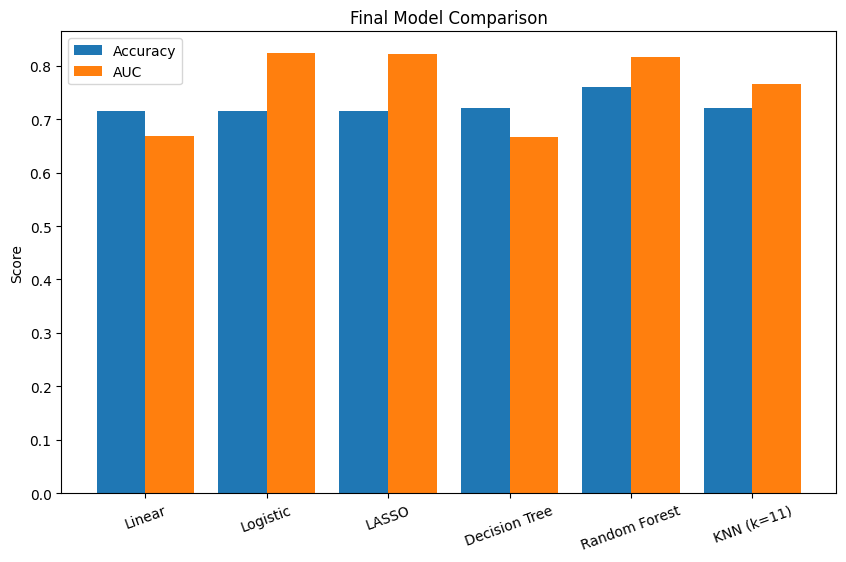

In [529]:
# Plot comparison

models_names = list(results.keys())
accuracy_vals = [results[m]["Accuracy"] for m in models_names]
auc_vals = [results[m]["AUC"] for m in models_names]

x = range(len(models_names))

plt.figure(figsize=(10,6))

# Accuracy
plt.bar(x, accuracy_vals, width=0.4, label='Accuracy')

# AUC
plt.bar([i + 0.4 for i in x], auc_vals, width=0.4, label='AUC')

plt.xticks([i + 0.2 for i in x], models_names, rotation=20)
plt.ylabel("Score")
plt.title("Final Model Comparison")
plt.legend()

plt.show()

## ** Key Insights**
-  Accuracy - proportion of correct predictions
-  AUC - Area Under ROC Curve
- Random Forest emerges as the best-performing model overall, achieving the highest accuracy and AUC, demonstrating strong predictive power and excellent ability to capture complex patterns in the data.
- Logistic Regression and LASSO show consistently strong and similar performance, indicating that the relationship between features and the target is reasonably well captured by linear decision boundaries, while LASSO adds the benefit of feature selection.
- The tuned KNN model (k = 11) shows moderate and stable performance, improving after optimization but still not outperforming ensemble methods, suggesting that distance-based approaches are less suited for this dataset.
- Decision Tree performs noticeably worse than other models, with lower AUC and less stable predictions, highlighting its tendency to overfit and poor generalization compared to ensemble techniques.
- Linear Regression records the lowest performance, confirming that it is not appropriate for classification tasks, as it cannot properly model binary outcomes or produce valid probability estimates.
- Across all models, ensemble and regularized methods (Random Forest and LASSO) provide better generalization and robustness, making them more reliable for real-world predictions.
- The comparison between train-test split and cross-validation suggests that cross-validation results are more stable and trustworthy, reinforcing the importance of using it for model evaluation.
- Overall, the dataset appears to favor models capable of handling non-linear relationships and feature interactions, which explains the superior performance of Random Forest over simpler models.

- The comparative analysis shows that Random Forest achieves the best performance, followed by Logistic Regression and LASSO, which provide stable and reliable predictions. The tuned KNN model performs moderately but does not exceed ensemble methods. Decision Tree shows weaker generalization, while Linear Regression performs poorly due to its incompatibility with classification tasks.